<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 22 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Transformations" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
rng = np.random.default_rng(222)
print("Ready.")

Ready.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · LOG THE SKEW</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Measure the change</div>
<div style="color:#4a5578;margin-top:6px">Generate a right-skewed sample with rng.lognormal(mean=2, sigma=0.9, size=3000). Report its skewness, apply a log, and report the skewness again. Which direction on the ladder did you move, and why does log need positive data?</div>
</div>

In [2]:
x = rng.lognormal(mean=2, sigma=0.9, size=3000)
print(f"raw skew      : {stats.skew(x):+.2f}")
print(f"log skew      : {stats.skew(np.log(x)):+.2f}")

raw skew      : +3.83
log skew      : -0.00


**Answer:** The raw data is strongly right-skewed (skew well above 1); after `np.log` the skew drops to near 0. Log is a step **down** the ladder of powers, which is the direction that pulls in a right tail. It requires **strictly positive** values because the log of zero is undefined and the log of a negative is not real, so for data with zeros use `log1p` or a shift, and for negatives use Yeo-Johnson.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · PICK THE DIRECTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Which way on the ladder?</div>
<div style="color:#4a5578;margin-top:6px">For each, say whether to go UP or DOWN the ladder of powers and name a transform: (a) strongly right-skewed income; (b) left-skewed exam scores (a ceiling near 100); (c) Poisson count data you want to variance-stabilize.</div>
</div>

In [3]:
rows = [
  ("(a) right-skewed income",      "DOWN", "log (or sqrt)"),
  ("(b) left-skewed exam scores",  "UP",   "square (x^2)"),
  ("(c) Poisson counts",           "DOWN", "square root"),
]
for case, dirn, t in rows: print(f"{case:30} | go {dirn:4} -> {t}")

(a) right-skewed income        | go DOWN -> log (or sqrt)
(b) left-skewed exam scores    | go UP   -> square (x^2)
(c) Poisson counts             | go DOWN -> square root


**Answer:** (a) **down** the ladder (log or sqrt) to pull in the right tail; (b) **up** the ladder (square) to pull in the left tail; (c) **down** to the **square root**, the variance-stabilizing transform for counts (Poisson variance is about equal to the mean). Right skew goes down, left skew goes up, that is the whole rule.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · STABILIZE THE VARIANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Square-root on counts</div>
<div style="color:#4a5578;margin-top:6px">Make two Poisson groups, one with mean 5 and one with mean 100. Show the raw variances track the means, then apply sqrt and show the variances become comparable.</div>
</div>

In [4]:
low  = rng.poisson(5, 3000)
high = rng.poisson(100, 3000)
print(f"raw  low : mean {low.mean():.1f}, var {low.var():.1f}")
print(f"raw  high: mean {high.mean():.1f}, var {high.var():.1f}")
print(f"sqrt low : var {np.sqrt(low).var():.3f}")
print(f"sqrt high: var {np.sqrt(high).var():.3f}")

raw  low : mean 5.0, var 5.1
raw  high: mean 99.9, var 99.5
sqrt low : var 0.297
sqrt high: var 0.251


**Answer:** Raw, the high-mean group has roughly 20x the variance of the low group, because for Poisson data the **variance equals the mean**. After the square root, both variances sit near **0.25**, comparable regardless of the mean. That is why the square root is the classic variance-stabilizing transform for counts.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · LET BOX-COX CHOOSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Auto-pick lambda</div>
<div style="color:#4a5578;margin-top:6px">Apply scipy.stats.boxcox to a right-skewed positive sample. Report the chosen lambda and what near-zero / near-0.5 / near-1 would each imply.</div>
</div>

In [5]:
x = rng.lognormal(mean=1.5, sigma=0.7, size=3000)
bc, lam = stats.boxcox(x)
print(f"chosen lambda = {lam:.3f}")
print(f"skew: raw {stats.skew(x):+.2f} -> Box-Cox {stats.skew(bc):+.2f}")

chosen lambda = -0.001
skew: raw +3.82 -> Box-Cox -0.00


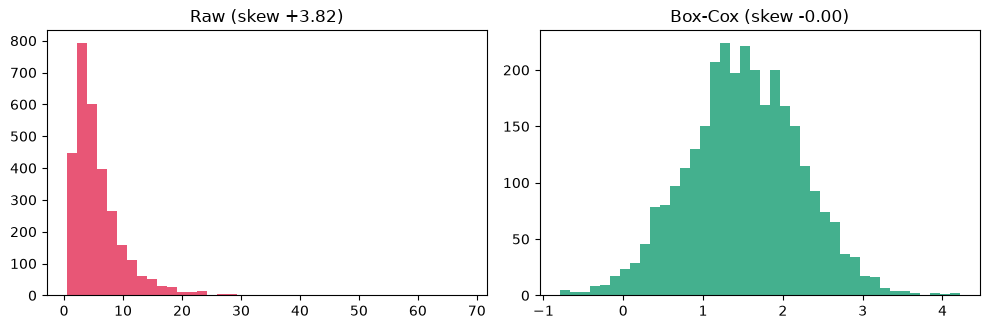

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(x, bins=40, color="#e11d48", alpha=0.75); ax[0].set_title(f"Raw (skew {stats.skew(x):+.2f})")
ax[1].hist(bc, bins=40, color="#059669", alpha=0.75); ax[1].set_title(f"Box-Cox (skew {stats.skew(bc):+.2f})")
plt.tight_layout(); plt.show()

**Answer:** Box-Cox returns the maximum-likelihood **lambda** that best normalizes the data (here near 0, so essentially a log). The lambda maps onto the ladder: **lambda≈1** means no transform needed, **lambda≈0.5** is square-root-like, **lambda≈0** is a log, and **lambda≈−1** is a reciprocal. Box-Cox needs **positive** data; for zeros or negatives use **Yeo-Johnson** (sklearn `PowerTransformer`).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · MIND THE BACK-TRANSFORM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Geometric vs arithmetic</div>
<div style="color:#4a5578;margin-top:6px">For a lognormal sample, compute the arithmetic mean, then exp(mean(log x)). Are they equal? Which should you report for a right-skewed quantity, and why?</div>
</div>

In [7]:
x = rng.lognormal(mean=3, sigma=1.0, size=5000)
arith = x.mean()
geo   = np.exp(np.log(x).mean())
print(f"arithmetic mean   : {arith:8.1f}")
print(f"exp(mean of logs) : {geo:8.1f}   (geometric mean)")
print(f"median            : {np.median(x):8.1f}")

arithmetic mean   :     32.8
exp(mean of logs) :     19.8   (geometric mean)
median            :     19.3


**Answer:** They are **not** equal: `exp(mean(log x))` is the **geometric mean**, which sits **below** the arithmetic mean (Jensen's inequality, because log is concave). Back-transforming a mean-of-logs systematically **underestimates** the arithmetic mean. For a right-skewed quantity, report the **median** (monotone transforms preserve it), or apply a bias correction such as Duan's smearing estimator. The headline lesson: results live on the transformed scale until you back-transform, and the mean does not survive the round trip cleanly.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You logged a skew away, chose the right rung for each case, stabilized count variance with a square root, let Box-Cox pick the power, and learned why the back-transformed mean is not the mean. Transformations reshape data on purpose, just remember to undo them honestly.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>